In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import re

In [2]:
df=pd.read_csv('Real_estate_DataCleaning_v2.csv')

In [3]:
df.head()

,F/H,sector,society,price,price_per_sqft,total_area(sqft),bedRoom,bathroom,balcony,additionalRoom,address,floorNum,agePossession,nearbyLocations,furnishDetails,features
0,1,81,signature global city 81,0.82,8639,949,2,2,3,0.0,"Sector 81, Sector 81 Gurgaon, Gurgaon, Haryana",2.0,undefined,"['Orris Community Center', 'HP Petrol Pump', '...","['1 Light', 'No AC', 'No Bed', 'No Chimney', '...",NaN
1,0,50,unitech nirvana birch court,11.95,36883,3240,3,3,2,"Study Room,Servant Room","Nirvana Country, Gurgaon, Haryana",1.0,5 to 10 Year Old,"['Radhakrishna Shani Mandir', 'Standard charte...","['1 Wardrobe', '1 Fan', '1 Geyser', '3 Light',...","['Feng Shui / Vaastu Compliant', 'Private Gard..."
2,1,107,signature global solera,0.28,5674,493,2,2,2,0.0,"Sector 107 Gurgaon, Gurgaon, Haryana",11.0,1 to 5 Year Old,"['Gurgaon Dreamz Mall', 'Dwarka Expressway', ""...","['1 Wardrobe', '3 Fan', '5 Light', 'No AC', 'N...","['Power Back-up', 'Lift(s)', 'Maintenance Staf..."
3,0,5,indepedent,3.50,14787,2367,5,4,2,"Pooja Room,Others","Sector 5 Gurgaon, Gurgaon, Haryana",2.0,10+ Year Old,"['Chintapurni Mandir', 'Sheetla Mata Mandir', ...",Unfurnished,"['Feng Shui / Vaastu Compliant', 'Private Gard..."
4,0,3,ashok vihar phase iii extension,0.40,8889,450,7,4,3,Pooja Room,"House No.183, Street Number 7, Ashok Vihar Pha...",4.0,0 to 1 Year Old,"['Palam Vihar Vyapar kendra', 'Palam triangle'...","['3 Fan', '15 Light', '1 Wardrobe', 'No AC', '...",['Water Storage']


### Furnish Details

In [4]:
pd.set_option('display.max_rows',None)
df.sample(5)[['furnishDetails','features']]

,furnishDetails,features
1277,"['11 Fan', '1 Exhaust Fan', '6 Geyser', '30 Li...","['Security / Fire Alarm', 'Feng Shui / Vaastu ..."
1361,"['2 Wardrobe', '1 Water Purifier', '5 Fan', '1...","['Security / Fire Alarm', 'Lift(s)', 'Water pu..."
3000,"['1 Exhaust Fan', '1 Geyser', '1 Modular Kitch...","['Security / Fire Alarm', 'Intercom Facility',..."
1544,"['4 AC', 'No Bed', 'No Chimney', 'No Curtains'...","['Feng Shui / Vaastu Compliant', 'Security / F..."
1916,Unfurnished,NaN


In [5]:
df['furnishDetails']=df['furnishDetails'].replace('Unfurnished',np.nan)

In [6]:
df.loc[3620]

F/H                                                                 1
sector                                                             35
society                                          breez global heights
price                                                            0.25
price_per_sqft                                                   7002
total_area(sqft)                                                  357
bedRoom                                                             1
bathroom                                                            1
balcony                                                             1
additionalRoom                                                    0.0
address                                  106, Sohna, Gurgaon, Haryana
floorNum                                                          1.0
agePossession                                         1 to 5 Year Old
nearbyLocations     ['Raheja Mall', 'Golf Course Extension Road', ...
furnishDetails      

In [7]:
##Extract all unique furnishings from the furnishDetails column
all_furnishings = []
for detail in df['furnishDetails'].dropna():
    furnishings = detail.replace('[', '').replace(']', '').replace("'", "").split(', ')
    all_furnishings.extend(furnishings)
unique_furnishings = list(set(all_furnishings))

# Define a function to extract the count of a furnishing from the furnishDetails
def get_furnishing_count(details, furnishing):
    if isinstance(details, str):
        if f"No {furnishing}" in details:
            return 0
        pattern = re.compile(f"(\d+) {furnishing}")
        match = pattern.search(details)
        if match:
            return int(match.group(1))
        elif furnishing in details:
            return 1
    return 0

# Simplify the furnishings list by removing "No" prefix and numbers
columns_to_include = [re.sub(r'No |\d+', '', furnishing).strip() for furnishing in unique_furnishings]
columns_to_include = list(set(columns_to_include))  # Get unique furnishings
columns_to_include = [furnishing for furnishing in columns_to_include if furnishing]  # Remove empty strings

# Create new columns for each unique furnishing and populate with counts
for furnishing in columns_to_include:
    df[furnishing] = df['furnishDetails'].apply(lambda x: get_furnishing_count(x, furnishing))

# Create the new dataframe with the required columns
furnishings_df = df[['furnishDetails'] + columns_to_include]


<>:13: SyntaxWarning: invalid escape sequence '\d'
<>:13: SyntaxWarning: invalid escape sequence '\d'
C:\Users\HP\AppData\Local\Temp\ipykernel_16236\2619030012.py:13: SyntaxWarning: invalid escape sequence '\d'
  pattern = re.compile(f"(\d+) {furnishing}")


In [8]:
furnishings_df.shape

(3904, 19)

In [9]:
furnishings_df.sample(5)

,furnishDetails,Stove,Washing Machine,Sofa,Microwave,Chimney,Curtains,Light,AC,Bed,Fridge,Dining Table,Water Purifier,Geyser,Exhaust Fan,TV,Fan,Wardrobe,Modular Kitchen
54,"['3 Wardrobe', '5 Fan', '14 Light', 'No AC', '...",0,0,0,0,0,0,14,0,0,0,0,0,0,0,0,5,3,0
181,NaN,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
577,"['1 Light', 'No AC', 'No Bed', 'No Chimney', '...",0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0
441,"['3 Fan', '6 Light', '3 AC', '1 Chimney', '1 W...",0,0,0,0,1,0,6,3,0,0,0,0,0,0,0,3,1,0
3068,NaN,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [10]:
furnishings_df.drop(columns=['furnishDetails'],inplace=True)

C:\Users\HP\AppData\Local\Temp\ipykernel_16236\114705885.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  furnishings_df.drop(columns=['furnishDetails'],inplace=True)


In [11]:
df.head()

,F/H,sector,society,price,price_per_sqft,total_area(sqft),bedRoom,bathroom,balcony,additionalRoom,...,Bed,Fridge,Dining Table,Water Purifier,Geyser,Exhaust Fan,TV,Fan,Wardrobe,Modular Kitchen
0,1,81,signature global city 81,0.82,8639,949,2,2,3,0.0,...,0,0,0,0,0,0,0,0,0,0
1,0,50,unitech nirvana birch court,11.95,36883,3240,3,3,2,"Study Room,Servant Room",...,0,0,0,0,1,0,0,1,1,1
2,1,107,signature global solera,0.28,5674,493,2,2,2,0.0,...,0,0,0,0,0,0,0,3,1,0
3,0,5,indepedent,3.50,14787,2367,5,4,2,"Pooja Room,Others",...,0,0,0,0,0,0,0,0,0,0
4,0,3,ashok vihar phase iii extension,0.40,8889,450,7,4,3,Pooja Room,...,0,0,0,0,0,0,0,3,1,0


In [12]:
### Standard scaling
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
scaled_data=scaler.fit_transform(furnishings_df)

In [13]:
from sklearn.cluster import KMeans
wcss_reduced=[]

for i in range(1,11):
    kmeans=KMeans(n_clusters=i,init='k-means++',random_state=42)
    kmeans.fit(scaled_data)
    wcss_reduced.append(kmeans.inertia_)


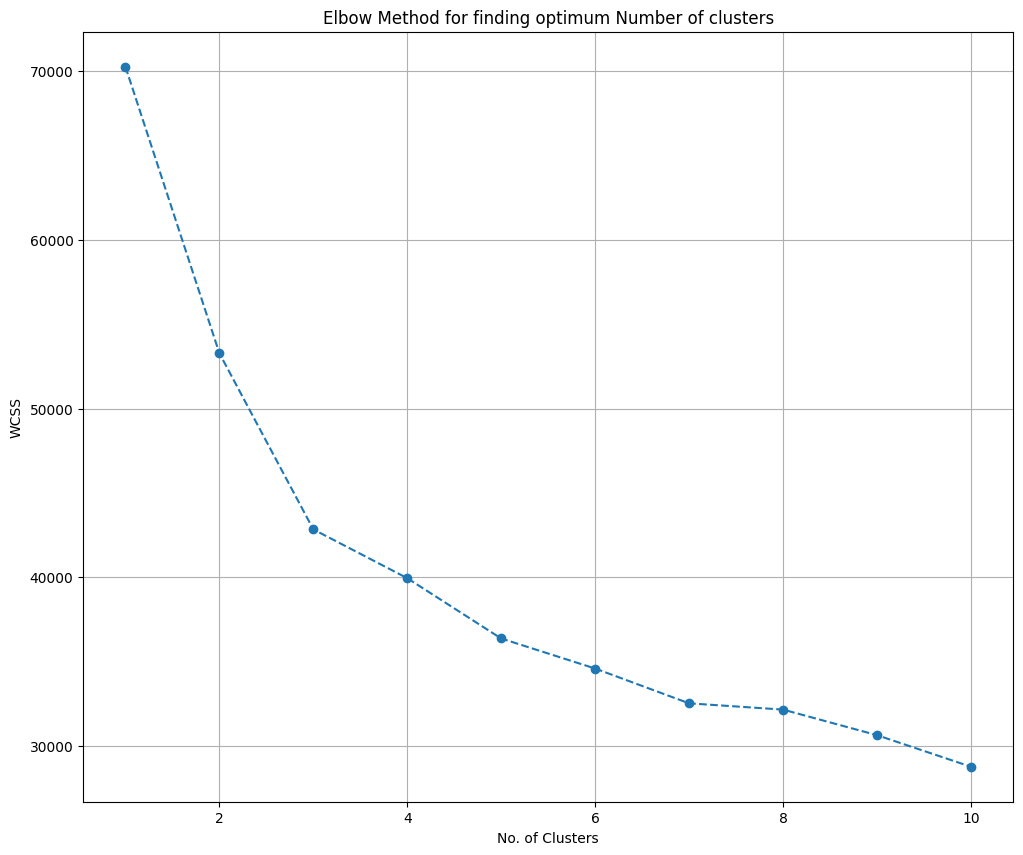

In [14]:
plt.figure(figsize=(12,10))
plt.plot(range(1,11),wcss_reduced,marker='o',linestyle='--')
plt.title('Elbow Method for finding optimum Number of clusters')
plt.xlabel('No. of Clusters')
plt.ylabel('WCSS')
plt.grid(True)
plt.show()

In [15]:
n_cluster=3
kmeans=KMeans(n_clusters=n_cluster,random_state=42)
kmeans.fit(scaled_data)
clusterAssign=kmeans.predict(scaled_data)
    

In [16]:
clusterAssign

array([0, 0, 0, ..., 0, 0, 0], shape=(3904,), dtype=int32)

In [17]:
df = df.iloc[:,:-18]

In [18]:
df['furnishing_type'] = clusterAssign

In [19]:
pd.set_option('display.max_rows',None)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)

In [20]:
df.sample(5)[['furnishDetails','furnishing_type']]

,furnishDetails,furnishing_type
3402,"['1 Fridge', '5 Fan', '1 Exhaust Fan', '3 Geyser', '1 Stove', '10 Light', '1 Chimney', '5 AC', '1 Modular Kitchen', '4 Wardrobe', '1 Sofa', '1 Microwave', '1 Washing Machine', 'No Bed', 'No Curtains', 'No Dining Table', 'No TV', 'No Water Purifier']",1
1366,NaN,0
457,"['1 Wardrobe', '1 Water Purifier', '12 Fan', '1 Exhaust Fan', '10 Geyser', '1 Microwave', '41 Light', '10 AC', '1 Chimney', 'No Bed', 'No Curtains', 'No Dining Table', 'No Modular Kitchen', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Washing Machine']",2
942,NaN,0
2051,"['1 Bed', '1 Wardrobe', '1 Water Purifier', '3 Fan', '1 Exhaust Fan', '8 Light', '1 AC', '1 Modular Kitchen', '6 Curtains', 'No Chimney', 'No Dining Table', 'No Geyser', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Washing Machine']",2


In [21]:
df.sample(3)

,F/H,sector,society,price,price_per_sqft,total_area(sqft),bedRoom,bathroom,balcony,additionalRoom,address,floorNum,agePossession,nearbyLocations,furnishDetails,features,furnishing_type
1717,1,86,dlf the skycourt,1.35,6998,1929,3,3,1,0.0,"Sector 86 Gurgaon, Gurgaon, Haryana",9.0,1 to 5 Year Old,"['Sapphire 83 Mall', 'NH-8, Imt Manesar', 'Rao Bharat Singh International School', 'DPG Institute of Technology', 'Aarvy Healthcare', 'Indira Gandhi International Airport', 'Imt Manesar', 'Holiday Inn Hotel Sector 90', 'Aapno Ghar', 'National Tennis Academy Sector 98']","['3 Wardrobe', '3 Fan', '4 Light', '3 AC', 'No Bed', 'No Chimney', 'No Curtains', 'No Dining Table', 'No Exhaust Fan', 'No Geyser', 'No Modular Kitchen', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Washing Machine', 'No Water Purifier']","['Security / Fire Alarm', 'Power Back-up', 'Private Garden / Terrace', 'Intercom Facility', 'Lift(s)', 'Centrally Air Conditioned', 'High Ceiling Height', 'Maintenance Staff', 'Water Storage', 'Bank Attached Property', 'Piped-gas', 'Visitor Parking', 'Swimming Pool', 'Park', 'Security Personnel', 'Natural Light', 'Spacious Interiors', 'Fitness Centre / GYM', 'Waste Disposal', 'Rain Water Harvesting', 'Club house / Community Center']",0
3244,1,25,dlf belvedere towers,3.70,17619,2100,4,4,3,1.0,"DLF Phase 2, Gurgaon, Haryana",18.0,10+ Year Old,"['Vodafone belvedere towers metro station', 'Dlf phase 2 metro station', 'Dlf phase 3 metro station', 'Indusind bank cyber city metro station', 'Sikandarpur metro station', 'Shri Shiv Shakthi Mandir', 'Jain Bhawan', 'Arya Samaj Mandir', 'Central bank atm teste 001112', 'Central bank ATM', 'Kotak mahindra ATM', 'Citibank ATM', 'Abn amro bank ATM', 'Axis bank ATM', 'Surgi Center Clinic', 'Kailash Nursing Home Gurgaon', 'RBS Dental Clinic', 'Cosmodentz Dental Clinic', 'Uma Sanjeevani Health Centre And Hospital', 'Relief Physiotherapy Clinic', 'Darpan Skin & Mind Clinic', 'Durga Poly Clinic', 'Krishna Family Clinic', 'Guardian', '98.4', 'Religare Wellness', 'Shri Balaji Medical Store', 'DLF Cyber City Phase II', 'Emaar Business Park', 'Standard chartered bank', 'Icici bank', 'Deutsche bank', 'Hsbc bank', 'Kotak mahindra bank', 'Axis bank', 'PVR Cinames', 'Mukesh Dhaba', 'Mc Donalds', ""McDonald's"", 'Food Court', 'The God Father', 'Cantine', 'barrique', 'American Montessori']","['4 Wardrobe', '7 Fan', '5 Geyser', '10 Light', '1 Chimney', '6 AC', 'No Bed', 'No Curtains', 'No Dining Table', 'No Exhaust Fan', 'No Modular Kitchen', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Washing Machine', 'No Water Purifier']","['Feng Shui / Vaastu Compliant', 'Intercom Facility', 'Lift(s)', 'Maintenance Staff', 'Park']",2
3305,1,107,signature global solera,0.28,5828,480,2,2,2,0.0,"Sector 107 Gurgaon, Gurgaon, Haryana",NaN,1 to 5 Year Old,"['Gurgaon Dreamz Mall', 'Dwarka Expressway', ""Colonel's Central Academy"", 'The NorthCap University', 'Chirag Hospital', 'Indira Gandhi International Airport', 'Trident Hotel Gurgaon', 'Fun N Food Village', 'DLF Golf and Country Club', 'F9 Go Karting Gurgaon', 'SkyJumper Trampoline Park Gurgaon']","['1 Wardrobe', '2 Fan', '1 Exhaust Fan', '2 Light', '1 Modular Kitchen', 'No AC', 'No Bed', 'No Chimney', 'No Curtains', 'No Dining Table', 'No Geyser', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Washing Machine', 'No Water Purifier']","['Security / Fire Alarm', 'Intercom Facility', 'Lift(s)', 'Maintenance Staff', 'Park', 'Shopping Centre', 'Fitness Centre / GYM']",0


### Age Possession

In [22]:
df['agePossession'].value_counts()

agePossession
1 to 5 Year Old       1686
5 to 10 Year Old       599
0 to 1 Year Old        543
undefined              354
10+ Year Old           345
within 1 year          152
Under Construction      87
Within 6 months         69
within 2-3 years        42
Within 3 months         26
Name: count, dtype: int64

In [23]:
df.loc[(df['agePossession']=='0 to 1 Year Old') | (df['agePossession']=='Within 6 months') | (df['agePossession']=='Within 3 months'),'agePossession']='Relatively New'

In [24]:
df['agePossession'].value_counts()

agePossession
1 to 5 Year Old       1686
Relatively New         638
5 to 10 Year Old       599
undefined              354
10+ Year Old           345
within 1 year          152
Under Construction      87
within 2-3 years        42
Name: count, dtype: int64

In [25]:
df.loc[(df['agePossession']=='1 to 5 Year Old') ,'agePossession' ]='New'
df.loc[(df['agePossession']=='5 to 10 Year Old') ,'agePossession']='Relatively Old'
df.loc[(df['agePossession']=='10+ Year Old') ,'agePossession']='Old'
df.loc[(df['agePossession']=='Under Construction') | (df['agePossession']=='within 1 year')|(df['agePossession']=='within 2-3 years'),'agePossession']='Under Construction'

### ADDITIONAL ROOM

In [26]:
df['additionalRoom']=df['additionalRoom'].str.lower()

In [27]:
df['additionalRoom'].value_counts()

additionalRoom
0.0                                              1287
1.0                                              1245
0                                                 367
2.0                                               322
servant room                                       80
pooja room,study room,servant room,store room      62
3.0                                                58
4.0                                                57
others                                             55
pooja room                                         38
pooja room,study room,servant room                 33
store room                                         31
pooja room,study room,servant room,others          27
pooja room,servant room                            24
study room,servant room                            18
study room                                         17
servant room,store room                            12
pooja room,others                                  11
pooja room,st

In [28]:
def count_rooms(val):
    
    if pd.isna(val):
        return 0.0
    
    val = str(val).strip()
    
    # 1. Empty or zero
    if val in ['', '0', '0.0']:
        return 0.0
    
    # 2. Numeric values
    elif val.replace('.', '', 1).isdigit():
        return float(val)
    
    # 3. String with multiple rooms
    elif ',' in val:
        return float(len([i for i in val.split(',') if i.strip() != ""]))
    
    # 4. Single room string
    elif isinstance(val, str):
        return 1.0
    
    # fallback
    else:
        return 0.0


df['additional_room_count'] = df['additionalRoom'].apply(count_rooms)

In [29]:
df.sample(5)

,F/H,sector,society,price,price_per_sqft,total_area(sqft),bedRoom,bathroom,balcony,additionalRoom,address,floorNum,agePossession,nearbyLocations,furnishDetails,features,furnishing_type,additional_room_count
1493,1,69,tulip violet,1.55,9822,1578,3,3,2,1.0,"Sector 69 Gurgaon, Gurgaon, Haryana",5.0,New,"['Airia Mall Sector 68', 'Southern Peripheral Road', 'Golf Course Extension Rd', 'Imperio School', 'DPG Institute of Technology', 'Ektaa Hospitals', 'Indira Gandhi International Airport', 'Vipul Trade Business Centre', 'Radisson Hotel Gurugram', 'SkyJumper Trampoline Park']",[],"['Power Back-up', 'Feng Shui / Vaastu Compliant', 'Intercom Facility', 'Lift(s)', 'High Ceiling Height', 'Maintenance Staff', 'False Ceiling Lighting', 'Water Storage', 'Separate entry for servant room', 'No open drainage around', 'Piped-gas', 'Visitor Parking', 'Swimming Pool', 'Park', 'Internet/wi-fi connectivity', 'Shopping Centre', 'Fitness Centre / GYM', 'Waste Disposal', 'Rain Water Harvesting', 'Club house / Community Center', 'Water softening plant']",0,1.0
2191,0,1,indepedent,10.00,122222,818,4,4,3,servant room,"Hsiidc Plot Sector 1 Imt Manesar, Gurgaon, Haryana",1.0,undefined,NaN,NaN,"['Feng Shui / Vaastu Compliant', 'Piped-gas', 'Rain Water Harvesting']",0,1.0
2038,1,51,orchid island,0.71,7891,900,2,2,1,0.0,"Sector 51 Gurgaon, Gurgaon, Haryana",4.0,New,"['Rapid Metro Sector 55-56', 'Tigra Market', 'Garima Public School', 'Gurugram University', 'ISKCON Temple', 'Artemis Hospital', 'IGI Airport', 'APJ Abdul Kalam Park', 'Imperfecto Patio']",[],"['Power Back-up', 'Maintenance Staff', 'Park', 'Security Personnel', 'Club house / Community Center']",0,0.0
1457,1,85,ss the leaf,2.13,7574,2812,4,4,3,0.0,"Sector 85 Gurgaon, Gurgaon, Haryana",6.0,New,"['Sapphire 83 Mall', 'Dwarka Expressway', 'Central Peripheral Road', 'NH 08', 'Pataudi Road', 'Delhi Public School Sector 84', 'DPG Institute of Technology', 'Genesis Hospital Sector 84', 'Indira Gandhi International Airport', 'Imt Manesar', 'Holiday Inn Hotel Sector 90', 'SkyJumper Trampoline Park', 'Nakhrola Stadium Sector 81A']","['6 AC', 'No Bed', 'No Chimney', 'No Curtains', 'No Dining Table', 'No Exhaust Fan', 'No Fan', 'No Geyser', 'No Modular Kitchen', 'No Light', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Wardrobe', 'No Washing Machine', 'No Water Purifier']","['Feng Shui / Vaastu Compliant', 'Security / Fire Alarm', 'Intercom Facility', 'Maintenance Staff', 'Water Storage', 'Park', 'Visitor Parking']",0,0.0
3268,1,35,signature global park,0.68,8252,824,2,2,2,0.0,"Sohna, Gurgaon, Haryana",3.0,Relatively New,"['Sector 55-56 metro', 'Global city centre', 'Sohna road dhunela', 'Gd goenka university', 'Maharana pratap school', 'Vardaan hospital and trauma centre', 'Indira Gandhi International Airport', 'Garhi harsaru railway station Gurgaon']","['2 Wardrobe', '3 Fan', '3 Light', '1 Modular Kitchen', 'No AC', 'No Bed', 'No Chimney', 'No Curtains', 'No Dining Table', 'No Exhaust Fan', 'No Geyser', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Washing Machine', 'No Water Purifier']","['Security / Fire Alarm', 'Feng Shui / Vaastu Compliant', 'Intercom Facility', 'Lift(s)', 'Maintenance Staff', 'Water Storage', 'Visitor Parking', 'Swimming Pool', 'Park', 'Security Personnel', 'Natural Light', 'Airy Rooms', 'Spacious Interiors', 'Low Density Society', 'Shopping Centre', 'Fitness Centre / GYM', 'Club house / Community Center']",0,0.0


## Features

In [30]:
app_df=pd.read_csv('appartments.csv')

app_df.head()

,PropertyName,PropertySubName,NearbyLocations,LocationAdvantages,Link,PriceDetails,TopFacilities
0,Smartworld One DXP,"2, 3, 4 BHK Apartment in Sector 113, Gurgaon","['Bajghera Road', 'Palam Vihar Halt', 'DPSG Palam Vihar', 'Park Hospital', 'Gurgaon Railway Station']","{'Bajghera Road': '800 Meter', 'Palam Vihar Halt': '2.5 KM', 'DPSG Palam Vihar': '3.1 KM', 'Park Hospital': '3.1 KM', 'Gurgaon Railway Station': '4.9 KM', 'The NorthCap University': '5.4 KM', 'Dwarka Expy': '1.2 KM', 'Hyatt Place Gurgaon Udyog Vihar': '7.7 KM', 'Dwarka Sector 21, Metro Station': '7.2 KM', 'Pacific D21 Mall': '7.4 KM', 'Indira Gandhi International Airport': '14.7 KM', 'Hamoni Golf Camp': '6.2 KM', 'Fun N Food Waterpark': '8.8 KM', 'Accenture DDC5': '9 KM'}",https://www.99acres.com/smartworld-one-dxp-sector-113-gurgaon-npxid-r400415,"{'2 BHK': {'building_type': 'Apartment', 'area_type': 'Carpet Area', 'area': '1,370 sq.ft.', 'price-range': '₹ 2 - 2.4 Cr'}, '3 BHK': {'building_type': 'Apartment', 'area_type': 'Carpet Area', 'area': '1,850 - 2,050 sq.ft.', 'price-range': '₹ 2.25 - 3.59 Cr'}, '4 BHK': {'building_type': 'Apartment', 'area_type': 'Carpet Area', 'area': '2,600 sq.ft.', 'price-range': '₹ 3.24 - 4.56 Cr'}}","['Swimming Pool', 'Salon', 'Restaurant', 'Spa', 'Cafeteria', 'Sun Deck', '24x7 Security', 'Club House', 'Gated Community']"
1,M3M Crown,"3, 4 BHK Apartment in Sector 111, Gurgaon","['DPSG Palam Vihar Gurugram', 'The NorthCap University', 'Park Hospital, Palam Vihar', 'Pacific D21 Mall', 'Palam Vihar Halt Railway Station']","{'DPSG Palam Vihar Gurugram': '1.4 Km', 'The NorthCap University': '4.4 Km', 'Park Hospital, Palam Vihar': '1.4 Km', 'Pacific D21 Mall': '8.2 Km', 'Palam Vihar Halt Railway Station': '1.2 Km', 'Dwarka Sector 21 Metro Station': '8.1 Km', 'Dwarka Expressway': '450 m', 'Fun N Food Water Park': '8.1 Km', 'Indira Gandhi International Airport': '14.1 Km', 'Tau DeviLal Sports Complex': '11.2 Km', 'Hamoni Golf Camp': '5 Km', 'Hyatt Place': '6.1 Km', 'Altrade Business Centre': '11.2 Km'}",https://www.99acres.com/m3m-crown-sector-111-gurgaon-npxid-r404068,"{'3 BHK': {'building_type': 'Apartment', 'area_type': 'Super Built-up Area', 'area': '1,605 - 2,170 sq.ft.', 'price-range': '₹ 2.2 - 3.03 Cr'}, '4 BHK': {'building_type': 'Apartment', 'area_type': 'Super Built-up Area', 'area': '2,248 - 2,670 sq.ft.', 'price-range': '₹ 3.08 - 3.73 Cr'}}","['Bowling Alley', 'Mini Theatre', 'Manicured Garden', 'Swimming Pool', 'Flower Garden', 'Reading Lounge', 'Golf Course', 'Barbecue', 'Sauna']"
2,Adani Brahma Samsara Vilasa,"Land, 3, 4 BHK Independent Floor in Sector 63, Gurgaon","['AIPL Business Club Sector 62', 'Heritage Xperiential Learning School', 'CK Birla Hospital', 'Paras Trinity Mall Sector 63', 'Rapid Metro Station Sector 56']","{'AIPL Business Club Sector 62': '2.7 Km', 'Heritage Xperiential Learning School': '2 Km', 'CK Birla Hospital': '2.5 Km', 'Paras Trinity Mall Sector 63': '3.5 Km', 'Rapid Metro Station Sector 56': '3.8 Km', 'De Adventure Park': '6.8 Km', 'Golf Course Ext Rd': '99 Meter', 'DoubleTree by Hilton Hotel Gurgaon': '3.6 Km', 'KIIT College of Engineering Sohna Road': '8.4 Km', 'Mehrauli-Gurgaon Road': '11.8 Km', 'Indira Gandhi International Airport': '21.1 Km', 'Nirvana Rd': '160 Meter', 'TERI Golf Course': '8.7 Km'}",https://www.99acres.com/adani-brahma-samsara-vilasa-sector-63-gurgaon-npxid-r327995,"{'3 BHK': {'building_type': 'Independent Floor', 'area_type': 'Super Built-up Area', 'area': '1,800 - 3,150 sq.ft.', 'price-range': '₹ 2.43 - 15.75 Cr'}, '4 BHK': {'building_type': 'Independent Floor', 'area_type': 'Super Built-up Area', 'area': '2,750 - 4,500 sq.ft.', 'price-range': '₹ 3.36 - 22.5 Cr'}, 'Land': {'building_type': '', 'area_type': 'Plot Area', 'area': '500 - 4,329 sq.ft.', 'price-range': '₹ 2.05 - 41.13 Cr'}}","['Terrace Garden', 'Gazebo', 'Fountain', 'Amphitheatre', 'Party Lawn', 'Basketball Court', 'Badminton Court', 'Yoga/Meditation Area', 'Indoor Games']"
3,Sobha City,"2, 3, 4 BHK Apartment in S

In [31]:
df['features'].isnull().sum()

np.int64(689)

In [32]:
temp_df=df[df['features'].isnull()]
temp_df.shape

(689, 18)

In [33]:
## making appartments data in lower so that at time of join it matches with main df data
app_df['PropertyName']=app_df['PropertyName'].str.lower()

In [34]:
x=temp_df.merge(app_df,left_on='society',right_on='PropertyName',how='left')['TopFacilities']

In [35]:
df.loc[temp_df.index,'features']=x.values

In [36]:
df['features'].isnull().sum()

np.int64(536)

In [37]:
from sklearn.preprocessing import MultiLabelBinarizer
import ast
# Convert the string representation of lists in the 'features' column to actual lists
df['features_list'] = df['features'].apply(lambda x: ast.literal_eval(x) if pd.notnull(x) and x.startswith('[') else [])

# Use MultiLabelBinarizer to convert the features list into a binary matrix
mlb = MultiLabelBinarizer()
features_binary_matrix = mlb.fit_transform(df['features_list'])

# Convert the binary matrix into a DataFrame
features_binary_df = pd.DataFrame(features_binary_matrix, columns=mlb.classes_)

In [38]:
features_binary_df.sample(3)

,24/7 Power Backup,24/7 Water Supply,24x7 Security,ATM,Aerobics Centre,Air Hockey,Airy Rooms,Amphitheatre,Automated Car Wash,Badminton Court,Bank Attached Property,Banquet Hall,Bar/Chill-Out Lounge,Barbecue,Basketball Court,Beach Volley Ball Court,Billiards,Bowling Alley,Bus Shelter,Business Lounge,CCTV Camera Security,Cafeteria,Car Parking,Car wash area,Card Room,Centrally Air Conditioned,Changing Area,Children's Play Area,Cigar Lounge,Clinic,Club House,Club house / Community Center,Community Hall,Concierge Service,Conference room,Creche/Day care,Cricket Pitch,Doctor on Call,Earthquake Resistant,Entrance Lobby,False Ceiling Lighting,Feng Shui / Vaastu Compliant,Fire Fighting Systems,Fitness Centre / GYM,Flower Garden,Food Court,Foosball,Football,Fountain,Gated Community,Gazebo,Golf Course,Grocery Shop,Gymnasium,High Ceiling Height,High Speed Elevators,Infinity Pool,Intercom Facility,Internal Street Lights,Internet/wi-fi connectivity,Jacuzzi,Jogging Track,Landscape Garden,Laundry,Lawn Tennis Court,Library,Lift(s),Lounge,Low Density Society,Maintenance Staff,Manicured Garden,Medical Centre,Milk Booth,Mini Theatre,Multipurpose Court,Multipurpose Hall,Natural Light,Natural Pond,No open drainage around,Park,Party Lawn,Pergola,Piped Gas,Piped-gas,Pool Table,Power Back up Lift,Power Back-up,Private Garden / Terrace,Property Staff,RO System,Rain Water Harvesting,Reading Lounge,Recently Renovated,Reflexology Park,Restaurant,Salon,Sauna,School,Security / Fire Alarm,Security Personnel,Separate entry for servant room,Sewage Treatment Plant,Shopping Centre,Skating Rink,Solar Lighting,Solar Water Heating,Spa,Spacious Interiors,Squash Court,Steam Room,Sun Deck,Swimming Pool,Temple,Terrace Garden,Theatre,Toddler Pool,Valet Parking,Vastu Compliant,Video Door Security,Visitor Parking,Visitors Parking,Volley Ball Court,Waiting Lounge,Waste Disposal,Water Softener Plant,Water Storage,Water purifier,Water softening plant,Wi-Fi Connectivity,Yoga/Meditation Area
1910,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
502,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0
2187,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0


In [39]:
# Define the weights for each feature as provided
# Assigning weights based on perceived luxury contribution
weights = {
    '24/7 Power Backup': 8,
    '24/7 Water Supply': 4,
    '24x7 Security': 7,
    'ATM': 4,
    'Aerobics Centre': 6,
    'Airy Rooms': 8,
    'Amphitheatre': 7,
    'Badminton Court': 7,
    'Banquet Hall': 8,
    'Bar/Chill-Out Lounge': 9,
    'Barbecue': 7,
    'Basketball Court': 7,
    'Billiards': 7,
    'Bowling Alley': 8,
    'Business Lounge': 9,
    'CCTV Camera Security': 8,
    'Cafeteria': 6,
    'Car Parking': 6,
    'Card Room': 6,
    'Centrally Air Conditioned': 9,
    'Changing Area': 6,
    "Children's Play Area": 7,
    'Cigar Lounge': 9,
    'Clinic': 5,
    'Club House': 9,
    'Concierge Service': 9,
    'Conference room': 8,
    'Creche/Day care': 7,
    'Cricket Pitch': 7,
    'Doctor on Call': 6,
    'Earthquake Resistant': 5,
    'Entrance Lobby': 7,
    'False Ceiling Lighting': 6,
    'Feng Shui / Vaastu Compliant': 5,
    'Fire Fighting Systems': 8,
    'Fitness Centre / GYM': 8,
    'Flower Garden': 7,
    'Food Court': 6,
    'Foosball': 5,
    'Football': 7,
    'Fountain': 7,
    'Gated Community': 7,
    'Golf Course': 10,
    'Grocery Shop': 6,
    'Gymnasium': 8,
    'High Ceiling Height': 8,
    'High Speed Elevators': 8,
    'Infinity Pool': 9,
    'Intercom Facility': 7,
    'Internal Street Lights': 6,
    'Internet/wi-fi connectivity': 7,
    'Jacuzzi': 9,
    'Jogging Track': 7,
    'Landscape Garden': 8,
    'Laundry': 6,
    'Lawn Tennis Court': 8,
    'Library': 8,
    'Lounge': 8,
    'Low Density Society': 7,
    'Maintenance Staff': 6,
    'Manicured Garden': 7,
    'Medical Centre': 5,
    'Milk Booth': 4,
    'Mini Theatre': 9,
    'Multipurpose Court': 7,
    'Multipurpose Hall': 7,
    'Natural Light': 8,
    'Natural Pond': 7,
    'Park': 8,
    'Party Lawn': 8,
    'Piped Gas': 7,
    'Pool Table': 7,
    'Power Back up Lift': 8,
    'Private Garden / Terrace': 9,
    'Property Staff': 7,
    'RO System': 7,
    'Rain Water Harvesting': 7,
    'Reading Lounge': 8,
    'Restaurant': 8,
    'Salon': 8,
    'Sauna': 9,
    'Security / Fire Alarm': 9,
    'Security Personnel': 9,
    'Separate entry for servant room': 8,
    'Sewage Treatment Plant': 6,
    'Shopping Centre': 7,
    'Skating Rink': 7,
    'Solar Lighting': 6,
    'Solar Water Heating': 7,
    'Spa': 9,
    'Spacious Interiors': 9,
    'Squash Court': 8,
    'Steam Room': 9,
    'Sun Deck': 8,
    'Swimming Pool': 8,
    'Temple': 5,
    'Theatre': 9,
    'Toddler Pool': 7,
    'Valet Parking': 9,
    'Video Door Security': 9,
    'Visitor Parking': 7,
    'Water Softener Plant': 7,
    'Water Storage': 7,
    'Water purifier': 7,
    'Yoga/Meditation Area': 7
}
# Calculate luxury score for each row
luxury_score = features_binary_df[list(weights.keys())].multiply(list(weights.values())).sum(axis=1)

In [40]:
df['luxury_score']=luxury_score

In [41]:
df.sample()

,F/H,sector,society,price,price_per_sqft,total_area(sqft),bedRoom,bathroom,balcony,additionalRoom,address,floorNum,agePossession,nearbyLocations,furnishDetails,features,furnishing_type,additional_room_count,features_list,luxury_score
1585,1,95,siddhartha apartment,0.72,3664,1965,3,3,2,1.0,"F Block, Sector 95 Gurgaon, Gurgaon, Haryana",4.0,New,"['Yadav Clinic', 'Bangali Clinic', 'Dr. J. S. Sarkar Clinic', 'Vijay Petrol Pump']","['1 Wardrobe', '1 Modular Kitchen', 'No AC', 'No Bed', 'No Chimney', 'No Curtains', 'No Dining Table', 'No Exhaust Fan', 'No Fan', 'No Geyser', 'No Light', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Washing Machine', 'No Water Purifier']","['Lift(s)', 'Park', 'Maintenance Staff', 'Visitor Parking']",0,1.0,"[Lift(s), Park, Maintenance Staff, Visitor Parking]",21


In [42]:
df.drop(columns=['nearbyLocations','furnishDetails','features','features_list'],inplace=True)

In [43]:
df.sample()

,F/H,sector,society,price,price_per_sqft,total_area(sqft),bedRoom,bathroom,balcony,additionalRoom,address,floorNum,agePossession,furnishing_type,additional_room_count,luxury_score
1316,0,24,sector 37,0.55,7290,754,2,1,1,store room,"House No. 4, Narsinghpur, Gurgaon, Haryana",1.0,Relatively New,0,1.0,90


## SECTOR

In [44]:
df[df['sector'].isnull()]

,F/H,sector,society,price,price_per_sqft,total_area(sqft),bedRoom,bathroom,balcony,additionalRoom,address,floorNum,agePossession,furnishing_type,additional_room_count,luxury_score
183,0,NaN,indepedent,15.50,28233,5490,5,6,3,"pooja room,study room,servant room,store room","B Block Sushant Lok Phase 1, Gurgaon, Haryana",3.0,Relatively Old,0,4.0,76
444,0,NaN,indepedent,3.51,12342,2844,4,4,3,servant room,"Suncity, Gurgaon, Haryana",4.0,Relatively New,0,1.0,73
1004,0,NaN,indepedent,8.49,31444,2700,3,3,2,"pooja room,servant room","B Block Sushant Lok Phase 1, Gurgaon, Haryana",4.0,New,2,2.0,21
1894,0,NaN,indepedent,8.25,30556,2700,5,6,3,"study room,servant room,store room,pooja room","Sushant Lok, B Block Sushant Lok Phase 1, Gurgaon, Haryana",3.0,Relatively Old,2,4.0,64
2273,0,NaN,indepedent,5.50,38194,1440,18,18,3,servant room,"11111, Suncity, Gurgaon, Haryana",4.0,New,1,1.0,70


In [45]:
df.loc[[183,1004,1894],'society']='B Block Sushant Lok Phase 1'
df.loc[[183,1004,1894],'sector']='43'
df.loc[[2273,444],'society']='Suncity Township,Gurgaon,Haryana'
df.loc[[2273,444],'sector']='54'

### Exporting Dataset

In [46]:
df.to_csv('Real_estate_FeatureEng.csv')